# Практическая работа
# Компьютерное зрение
# Обучение с передачей знаний для распознавания повреждений глазной сетчатки
## Преамбула
В этой практической работе вы попробуете построить модель глубокой нейронной сети для определения класса повреждения глазной сетчатки по снимкам ОКТ.

Однако, глубокие нейронные сети требовательны к большим объемам данных для сходимости обучения. И зачастую в нашей частной задаче недостаточно данных для того, чтобы хорошо натренировать все слои нейросети. `Transfer Learning` (`обучение переносом`) решает эту проблему.

`Transfer Learning` (`трансферное обучение`) — это подраздел машинного обучения, целью которого является применение знаний, полученные из одной задачи, к другой целевой задаче.

Для таких типовых задач, как классификация изображений, можно воспользоваться готовой архитектурой (AlexNet, VGG, Inception, ResNet и т.д.) и обучить нейросеть на своих данных. Реализации таких сетей с помощью различных фреймворков уже существуют, так что в этой работе мы будем использовать одну из них как черный ящик, не вникая глубоко в принцип её работы.

Нейронные сети, которые используются для классификации, как правило, содержат $N$ выходных нейронов в последнем слое, где $N$ — это количество классов. Такой выходной вектор трактуется как набор вероятностей принадлежности к классу. В нашей задаче количество классов может отличаться от того, которое было в исходном датасете. В таком случае нам придётся полностью выкинуть этот последний слой и поставить новый, с нужным количеством выходных нейронов.

![Текст ссылки](https://habrastorage.org/r/w1560/webt/u_/n3/k3/u_n3k3qpkps6nw9tjjzwc0njl-y.jpeg)

[Вспомогательные материалы](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

## Данные

`Оптическая когерентная томография сетчатки (ОКТ)` $-$ это метод визуализации, используемый для получения поперечных срезов сетчатки живых пациентов с высоким разрешением. Ежегодно выполняется около 30 миллионов ОКТ-сканирований, и анализ и интерпретация этих изображений занимает значительное количество времени (Swanson and Fujimoto, 2017).

![Текст ссылки](https://i.imgur.com/fSTeZMd.png)

На рисунке представлены классы повреждений сетчатки:

* (Крайний слева) неоваскуляризация хориоидеи (CNV) с неоваскулярной мембраной (белые стрелки) и связанной с ней субретинальной жидкостью (стрелки);
* (Средний слева) Диабетический макулярный отек (ДМЭ) с интраретинальной жидкостью, связанной с утолщением сетчатки (стрелки);
* (Справа посередине) Множественные друзы (наконечники стрел) присутствуют на ранних стадиях ВМД;
*(Крайний справа) Нормальная сетчатка с сохраненным контуром ямки и отсутствием какой-либо жидкости / отека сетчатки.

В этой задаче вы будете работать действительно с большим набором данных. Код для скачивания данных представлен ниже. Скачивание занимает в среднем 5 минут.

In [1]:
import kagglehub


# Download latest version
path = kagglehub.dataset_download("paultimothymooney/kermany2018")

print("Path to dataset files:", path)

Resuming download from 27262976 bytes (11617019775 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/kermany2018?dataset_version_number=2 (27262976/11644282751) bytes left.


100%|███████████████████████████████████████████████████████████████████████████| 10.8G/10.8G [3:03:42<00:00, 1.05MB/s]

Extracting files...


FileNotFoundError: [WinError 3] Системе не удается найти указанный путь: 'C:\\Users\\79300\\.cache\\kagglehub\\datasets\\paultimothymooney\\kermany2018\\versions\\2\\OCT2017 \\test'

In [1]:
import os

# Проверяем, что папка существует
data_path = "./OCT2017"

if os.path.exists(data_path):
    print(f"✅ Папка найдена: {os.path.abspath(data_path)}")
    
    # Смотрим, что внутри
    contents = os.listdir(data_path)
    print(f"Содержимое: {contents[:10]}")  # первые 10 элементов
    print(f"Всего элементов: {len(contents)}")
else:
    print(f"❌ Папка не найдена: {data_path}")

✅ Папка найдена: C:\Users\79300\AGAT\step_7\OCT2017
Содержимое: ['test', 'train', 'val']
Всего элементов: 3


Объясняю: были проблемы со скачиванием, качал 10.8гб через kaggle. По итогу в конце выдало ошибку по несоответствию ( как мне сказал ИИ ) названий папок, в общем пришлось вручную уже с самого каггла качать архив, переносить в рабочую папку. Код брал от ИИ чтобы проверить, что все подгрузилось.

In [2]:
import os # модуль для работы с операционной системой
path = "./OCT2017"
os.listdir(path) # возвращает список вложенных в директорию с указанным путем объектов

['test', 'train', 'val']

Выберите директорию `OCT2017`. Лежащие в ней данные используйте для выполнения заданий.
Набор данных уже разделён на три выборки: `train`, `val` и `test`. Первые два поднабора будут использоваться для обучения, один $-$ для тестирования.

In [3]:
train_path = os.path.join(path, "train")
val_path = os.path.join(path, "val")
test_path = os.path.join(path, "test")

train_count = 0
for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        train_count += len(files)
print(f"Train: {train_count} файлов")
val_count = 0
for class_name in os.listdir(val_path):
    class_path = os.path.join(val_path, class_name)
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        val_count += len(files)
print(f"Val: {val_count} файлов")
test_count = 0
for class_name in os.listdir(test_path):
    class_path = os.path.join(test_path, class_name)
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        test_count += len(files)
print(f"Test: {test_count} файлов")
    

Train: 83484 файлов
Val: 32 файлов
Test: 968 файлов


## Построение модели

In [4]:
import torch
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


В этой задаче загрузить данные достаточно просто, если использовать класс `torchvision.datasets.ImageFolder`.

Что нужно сделать:
* Задайте необходимую цепочку преобразований для картинок, используя `torchvision.transofoms`. Загляните в документацию к этому модулю и найдите преобразования: случайная обрезка (обрежьте случайным образом картинки до размера 224x224), случайный поворот, превратите в `torch.Tensor`, как делали это в предыдущей работе;

* Соберите три датасета с помощью `torchvision.datasets.ImageFolder`;

* Создайте три загрузчика данных (`torch.utils.data.DataLoader`). Для каждого из них укажите размер батча, укажите параметр, отвечающий за перетасовку изображений внутри каждой папки (нам не важен порядок картинок, поэтому случайная перетасовка уберёт лишние зависимости, которым может обучиться модель).

In [5]:
from torch.utils.data import DataLoader
# обучающая выборка (агументация+)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),  # случайная обрезка до 224x224
    transforms.RandomRotation(15),       # случайный поворот на 15 градусов
    transforms.RandomHorizontalFlip(),   # случайное отражение
    transforms.ToTensor(),               # превращаем в тензор
    transforms.Normalize(                # нормализация (для ImageNet)
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# вал и тест выборка (аугментация-)
val_test_transform = transforms.Compose([
    transforms.Resize(256),              # изменяем размер
    transforms.CenterCrop(224),          # обрезаем центр до 224x224
    transforms.ToTensor(),               # превращаем в тензор
    transforms.Normalize(                # нормализация
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
train_dataset = datasets.ImageFolder(
    root=os.path.join(data_path, "train"), # указываем, в какой папке лежат изображения
    transform=train_transform # передаем цепочку преобразований
)
val_dataset = datasets.ImageFolder(
    root=os.path.join(data_path, "val"),
    transform=val_test_transform
)
test_dataset = datasets.ImageFolder(
    root=os.path.join(data_path, "test"),
    transform=val_test_transform
)
# создание батча
batch_size = 64
train_loader = DataLoader(
    train_dataset, # передаем датасет который сделал ImgaeFOlder
    batch_size=batch_size, # передаем значение батча
    shuffle=True,      # перемешиваем для обучения
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,     # для валидации не перемешиваем
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,     # для теста не перемешиваем
)

Покажите, какие изображения присутствуют в выборке. Напишите функцию `imshow`, выводящую на экран изображения в одном батче.

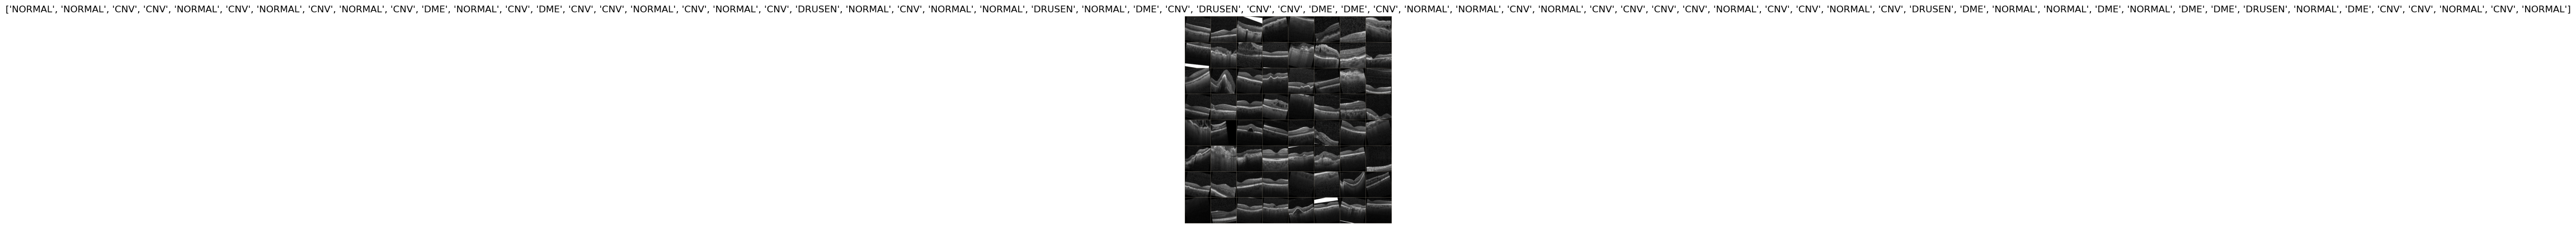

In [6]:
import numpy as np
class_names = train_dataset.classes
def imshow(inp, title=None):
    if torch.cuda.is_available():
        inp = inp.cpu()
    inp = inp.permute(1, 2, 0).detach().numpy() # permute - меняем порядок размерностей изображения, чтобы matplotlib мог принимать высота,ширина,каналы
    # detach был для отключения графов, numpy превращает тензор в numpy массив
    # денормализация, возвращение в диапазон от 0 до 1
    mean = np.array([0.485, 0.456, 0.406]) # среднее значение для каждого канала (R, G, B)
    std = np.array([0.229, 0.224, 0.225]) # стандартное отклонение для каждого канала (R, G, B)
    inp = std * inp + mean  # обратная формула: x = x_norm * std + mean
    inp = np.clip(inp, 0, 1)  # обрезаем значения вне [0, 1]
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

def show_databatch(inputs, classes):
    out = torchvision.utils.make_grid(inputs)
    imshow(out, title=[class_names[x] for x in classes])

# next позволяет сделать один шаг вперёд по загрузчику данных
inputs, classes = next(iter(train_loader))
show_databatch(inputs, classes)

Предобученная модель `VGG-16` способна классифицировать 1000 различных меток; нам просто нужно 4 вместо них. Чтобы сделать это, мы собираемся заменить последний полносвязный уровень модели на новый с 4 выходными нейронами вместо 1000.

В `PyTorch` мы можем получить доступ к классификатору `VGG-16` с помощью модуля `model.classifier`, который представляет собой 6-слойный массив. Мы заменим последнюю запись.

Скачайте и загрузите веса модели: [веса модели на kaggle](https://www.kaggle.com/datasets/pytorch/vgg16bn)

In [7]:
from torchvision import models

vgg16 = models.vgg16_bn()
vgg16.load_state_dict(torch.load("vgg16_bn.pth"))
print(vgg16.classifier[6].out_features) # 1000

1000


In [8]:
import torch.nn as nn
# заморозьте все уровни модели vgg16
for parameter in vgg16.parameters():
    parameter.requires_grad = False
# затем добавьте новый слой
num_features = vgg16.classifier[6].in_features
features = list(vgg16.classifier.children())[:-1] # удаляем последний (выходной) слой
features.extend([nn.Linear(num_features, 4)]) # добавьте полносвязный слой с 4-мя нейронами
vgg16.classifier = nn.Sequential(*features) # замените модель на новую в атрибуте classifier
print(vgg16)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

Выберите оптимизатор обучения модели и функцию потерь.

Саму модель перенесите на `gpu`.

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg16 = vgg16.to(device)
cross_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg16.classifier[6].parameters(), lr=0.001)

Напишите функции `train_model` для обучения и `eval_model` для оценки модели. Метрикой выберите `accuracy`. Предусмотрите, что эта модель может очень долго обучаться. Попробуйте предусмотреть сохранение весов очередной эпохи обучения и загрузку их в зависимости от какого-нибудь параметра параметра функции.

In [11]:
def eval_model(model, criterion, dataloader, device):
    model.eval() # все ровно также как в task 7
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

def train_model(model, criterion, optimizer, train_loader, val_loader, scheduler, num_epochs=5, save_path='best_model.pth', device='cuda'):
    model = model.to(device) # все ровно также как и в таск7
    best_val_acc = 0
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    for epoch in range(num_epochs):
        # начинаю обучение
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            # прямой проход
            outputs = model(images)
            loss = criterion(outputs, labels)
            # обратный проход
            optimizer.zero_grad()
            loss.backward()
            optimizer.step() 
            # статистика
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        
        # валидация
        val_loss, val_acc = eval_model(model, criterion, val_loader, device)
        # планировщик
        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()
        # история
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # вывод лучшей модели
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"Эпоха {epoch+1}: Новая лучшая модель! Acc = {val_acc:.4f}")
        
        # результат
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Эпоха {epoch+1}/{num_epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print(f"LR: {current_lr:.6f}")
        print("-" * 30)
    
    print("=" * 50)
    print(f"Обучение закончено! Лучшая точность: {best_val_acc:.4f}")
    print(f"Веса сохранены в: {save_path}")
    
    return train_losses, train_accs, val_losses, val_accs, best_val_acc

В конце оцените `accuracy` полученной модели.

In [12]:
num_epochs = 5
save_path = 'best_vgg16_oct.pth'
train_losses, train_accs, val_losses, val_accs, best_acc = train_model(
    model=vgg16,
    criterion=cross_loss,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    scheduler=None,
    num_epochs=num_epochs,
    save_path=save_path,
    device=device
)

print("\n" + "=" * 60)
print(f"Обучение завершено!")
print(f"Лучшая точность на валидации: {best_acc:.4f} ({best_acc*100:.2f}%)")

Эпоха 1: Новая лучшая модель! Acc = 0.7500
Эпоха 1/5
Train Loss: 0.8212, Train Acc: 0.6898
Val Loss: 0.6488, Val Acc: 0.7500
LR: 0.001000
------------------------------
Эпоха 2/5
Train Loss: 0.8117, Train Acc: 0.6964
Val Loss: 0.6379, Val Acc: 0.6875
LR: 0.001000
------------------------------
Эпоха 3/5
Train Loss: 0.8111, Train Acc: 0.6956
Val Loss: 0.5980, Val Acc: 0.7188
LR: 0.001000
------------------------------
Эпоха 4: Новая лучшая модель! Acc = 0.7812
Эпоха 4/5
Train Loss: 0.8123, Train Acc: 0.6976
Val Loss: 0.5491, Val Acc: 0.7812
LR: 0.001000
------------------------------
Эпоха 5/5
Train Loss: 0.8123, Train Acc: 0.6952
Val Loss: 0.6293, Val Acc: 0.7500
LR: 0.001000
------------------------------
Обучение закончено! Лучшая точность: 0.7812
Веса сохранены в: best_vgg16_oct.pth

Обучение завершено!
Лучшая точность на валидации: 0.7812 (78.12%)


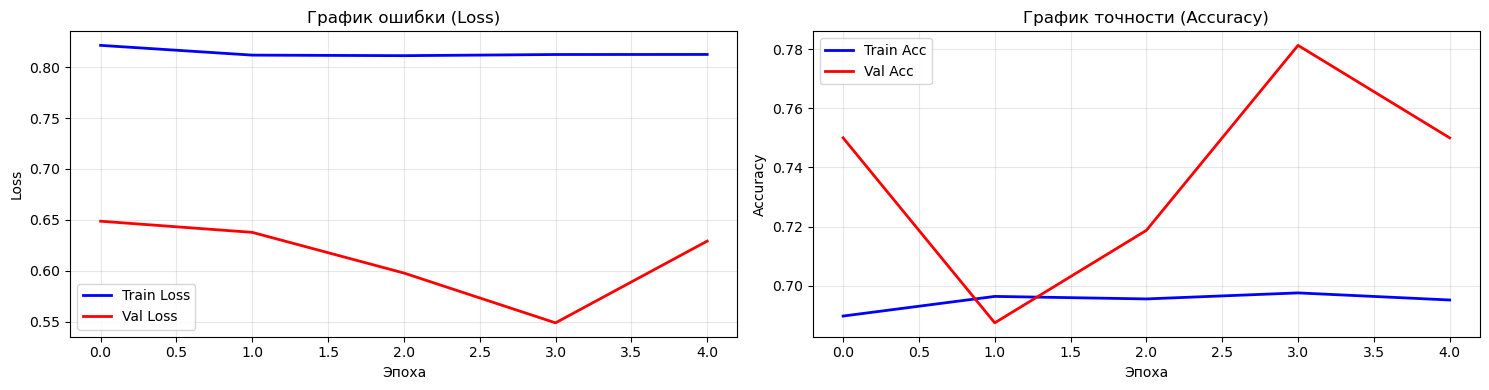

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# график 1: loss (ошибка)
axes[0].plot(train_losses, 'b-', label='Train Loss', linewidth=2)
axes[0].plot(val_losses, 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('График ошибки (Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# график 2: accuracy 
axes[1].plot(train_accs, 'b-', label='Train Acc', linewidth=2)
axes[1].plot(val_accs, 'r-', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('График точности (Accuracy)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Точность получил 78%
LR = 0.001
Train Loss: 0.8123, Train Acc: 0.6952
Val Loss: 0.6293, Val Acc: 0.7500